In [1]:
import os
from pathlib import Path

import pandas as pd

parent_dir = Path().cwd().parent
os.chdir(parent_dir)

from src.data_pipeline.loader import DataPreparer
from src.data_pipeline.pipeline_models import data_pipeline_settings

In [2]:
loader = DataPreparer(data_pipeline_settings)

df = loader.load_data()

In [3]:
df_avt = pd.read_csv("data/raw/avt_tags.csv", engine='pyarrow')
df_242000 = pd.read_csv("data/raw/242000_tags.csv", engine='pyarrow')

In [4]:
print((df['Unnamed: 0.1'] == df['Unnamed: 0']).all())
print((df['Unnamed: 0.1'] == df.index.to_series()).all())
print((df['Unnamed: 0.1'] == df.iloc[:, 74]).all())

True
True
True


столбцы полностью одинаквые, поэтому можем их удалить

In [5]:
df = loader.clean_data(df)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 189217 entries, 0 to 189216
Data columns (total 98 columns):
 #   Column  Non-Null Count   Dtype        
---  ------  --------------   -----        
 0   date    189217 non-null  datetime64[s]
 1   T1      189217 non-null  float64      
 2   P2      189217 non-null  float64      
 3   F3      189217 non-null  float64      
 4   P4      189217 non-null  float64      
 5   F5      189217 non-null  float64      
 6   T6_x    189217 non-null  float64      
 7   F7      189217 non-null  float64      
 8   F8      189217 non-null  float64      
 9   F9_x    189217 non-null  float64      
 10  D10     189217 non-null  int64        
 11  T11_x   189217 non-null  float64      
 12  F12     189217 non-null  float64      
 13  T13     189217 non-null  float64      
 14  F14_x   189217 non-null  float64      
 15  T15     189217 non-null  float64      
 16  F16     189217 non-null  float64      
 17  T17     189217 non-null  float64      
 18  T18_x   189217 

столбцы полностью одинаквые, поэтому можем их удалить

## Периоды простоя

Попробуем найти периоды когда аномалии были одновременно на большом колчестве датчиков, предположительно такие проблемы могут быть вызваны сбоями инфраструктуры(информаци не поступает нормально, перебои с питанием и ТД.)

In [6]:
def robust_z(s):
    med, mad = s.median(), (s - s.median()).abs().median()
    return (s - med) / (1.4826 * mad + 1e-9)

cont_cols = df.drop(columns=["date"]).columns #только столбцы с тэгами
z = df[cont_cols].apply(robust_z)
downtime_score = (z.abs() > 5).mean(axis=1)   # проверяет отклоняется ли z-score более чем на 5 стандартных отклонений и считает долю датчиков с таким отклонением с в строке
df['is_downtime'] = downtime_score > 0.3      # проверка на порог(от какой доли датчиков считаем даунтаймом)

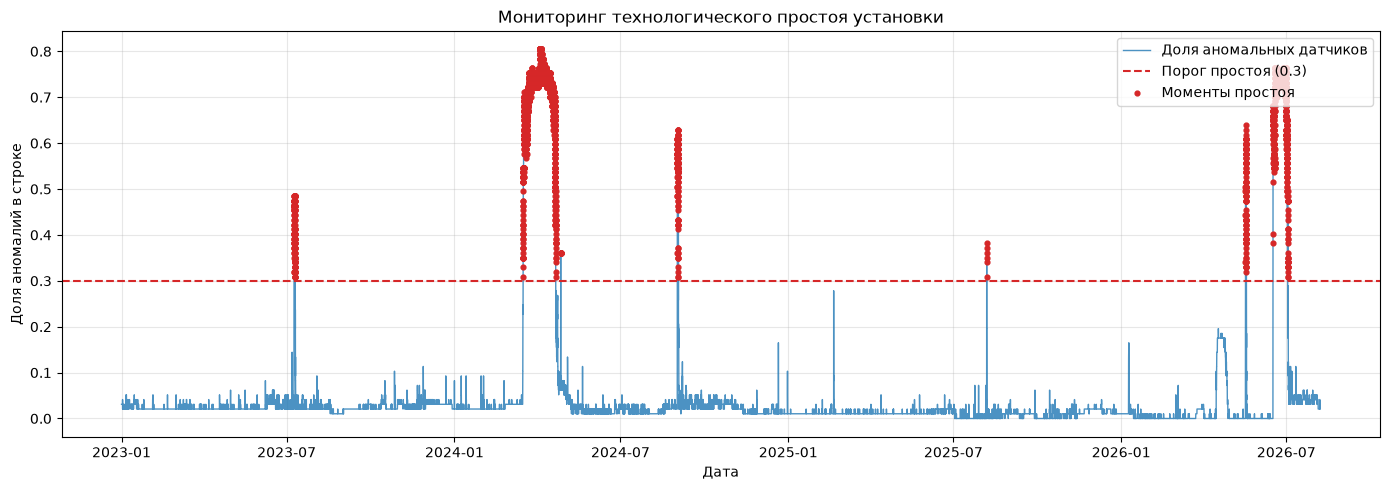

In [7]:
import matplotlib.pyplot as plt

# Убедимся, что колонка сохранена в датафрейме
df['downtime_score'] = downtime_score

plt.figure(figsize=(14, 5))

# 1. Линия общего индекса простоя во времени
plt.plot(df['date'], df['downtime_score'], label='Доля аномальных датчиков', color='tab:blue', alpha=0.8, linewidth=1)

# 2. Линия порога
plt.axhline(y=0.3, color='tab:red', linestyle='--', label='Порог простоя (0.3)', linewidth=1.5)

# 3. Подсветка точек, где сработал флаг простоя
downtime_points = df[df['is_downtime']]
plt.scatter(downtime_points['date'], downtime_points['downtime_score'], color='tab:red', s=12, label='Моменты простоя', zorder=5)

plt.xlabel('Дата')
plt.ylabel('Доля аномалий в строке')
plt.title('Мониторинг технологического простоя установки')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
corr = df.loc[~df['is_downtime'], cont_cols].corr().abs()

In [9]:
import numpy as np

upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pairs = upper.stack().sort_values(ascending=False)
suspects = pairs[pairs > 0.98]
print(suspects)

F9_y  F26_y    0.999912
P23   P67      0.999469
F56   F57      0.999316
T6_y  T11_y    0.997793
F59   F60      0.997365
T5    T6_y     0.995576
      T11_y    0.995363
F30   W70      0.987665
F17   F19_y    0.981300
dtype: float64


<Axes: xlabel='date'>

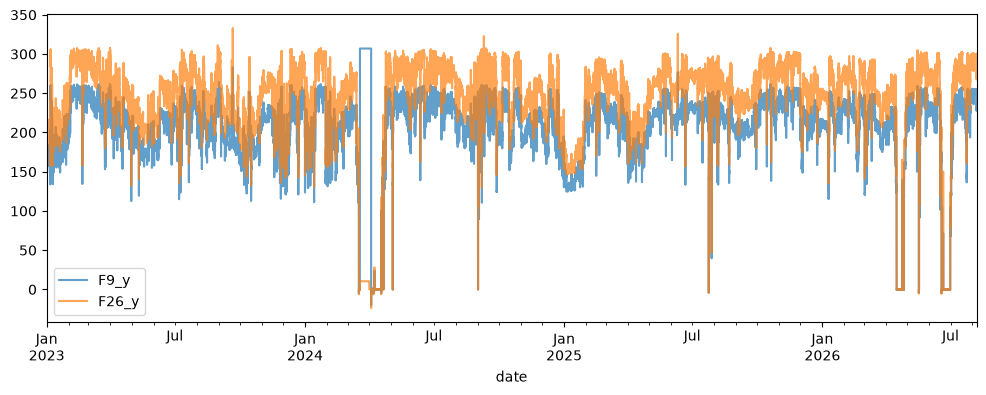

In [10]:
df.set_index('date')[['F9_y', 'F26_y']].plot(figsize=(12,4), alpha=0.7)

In [24]:
row = df.iloc[0].index
row[row != "date"]

Index(['T1', 'P2', 'F3', 'P4', 'F5', 'T6_x', 'F7', 'F8', 'F9_x', 'D10',
       'T11_x', 'F12', 'T13', 'F14_x', 'T15', 'F16', 'T17', 'T18_x', 'F19_x',
       'T20', 'P21', 'P22', 'P23', 'T24', 'F25_x', 'F26_x', 'F27', 'F28',
       'F29', 'F30', 'F31', 'F32', 'T33', 'F34', 'F35', 'F36', 'T37', 'T38',
       'T39', 'T40', 'F41', 'T42', 'L43', 'P44', 'F45', 'F46', 'T47', 'T48',
       'T49', 'P50', 'P51', 'P52', 'F53', 'F54', 'T55', 'F56', 'F57', 'T58',
       'F59', 'F60', 'T61', 'F62', 'F63', 'F64', 'F65', 'T66', 'P67', 'F68',
       'F69', 'W70', 'T71', 'F1', 'F2', 'P3', 'W4', 'T5', 'T6_y', 'W7', 'P8',
       'F9_y', 'W10', 'T11_y', 'T12', 'P13', 'F14_y', 'F15', 'T16', 'F17',
       'T18_y', 'F19_y', 'Q20', 'Q21', 'F22', 'T23', 'P24', 'F25_y', 'F26_y',
       'is_downtime', 'downtime_score'],
      dtype='str')